In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.backend import clear_session
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import load_model
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import opendatasets as od

In [ ]:
od.download('https://www.kaggle.com/datasets/alfanme/indonesian-batik-motifs-corak-app?select=DATASET')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: shintamaliiaa
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/alfanme/indonesian-batik-motifs-corak-app


100%|██████████| 156M/156M [00:09<00:00, 16.7MB/s]


In [ ]:
train_path = '/content/indonesian-batik-motifs-corak-app/DATASET/DATASET/TRAIN'
test_path = '/content/indonesian-batik-motifs-corak-app/DATASET/DATASET/TEST'

train_datagen = ImageDataGenerator(
  #  rescale=1./255,
    shear_range=0.2,
    rotation_range=30,
    fill_mode='reflect',
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

validation_datagen = ImageDataGenerator(
    #rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    directory=train_path,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=30,
    color_mode='rgb',
)

validation_generator = validation_datagen.flow_from_directory(
    directory=test_path,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=30,
    color_mode='rgb',
)

Found 1050 images belonging to 15 classes.
Found 300 images belonging to 15 classes.


In [ ]:
motives_dict = train_generator.class_indices
print(motives_dict)

{'Batik Bali': 0, 'Batik Betawi': 1, 'Batik Cendrawasih': 2, 'Batik Dayak': 3, 'Batik Geblek Renteng': 4, 'Batik Ikat Celup': 5, 'Batik Insang': 6, 'Batik Kawung': 7, 'Batik Lasem': 8, 'Batik Megamendung': 9, 'Batik Pala': 10, 'Batik Parang': 11, 'Batik Poleng': 12, 'Batik Sekar Jagad': 13, 'Batik Tambal': 14}


In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
#     alpha=1.0,
    pooling='avg'
)


base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
clear_session()

model = Sequential([
    base_model,
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(15, activation='softmax')
])


model.compile(
    optimizer=Adam(learning_rate=1e-4), #0.0001
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 1280)                │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,132,530 (15.76 MB)

 Trainable params: 82,959 (324.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    shuffle=True,
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 47s 567ms/step - accuracy: 0.0518 - loss: 2.8256 - val_accuracy: 0.1433 - val_loss: 2.6411
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 375ms/step - accuracy: 0.1527 - loss: 2.6215 - val_accuracy: 0.2233 - val_loss: 2.5006
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 371ms/step - accuracy: 0.1727 - loss: 2.5277 - val_accuracy: 0.3333 - val_loss: 2.3678
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 385ms/step - accuracy: 0.2846 - loss: 2.3859 - val_accuracy: 0.4100 - val_loss: 2.2398
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 372ms/step - accuracy: 0.3031 - loss: 2.2509 - val_accuracy: 0.4467 - val_loss: 2.1126
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 372ms/step - accuracy: 0.3769 - loss: 2.1477 - val_accuracy: 0.4600 - val_loss: 1.9997
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 372ms/step - accuracy: 0.4306 - loss: 2.0266 - val_accuracy: 0.4900 - val_loss: 1.8971
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 368ms/step - accuracy: 0.4501 - loss: 1.9390 - val_accuracy: 0.516

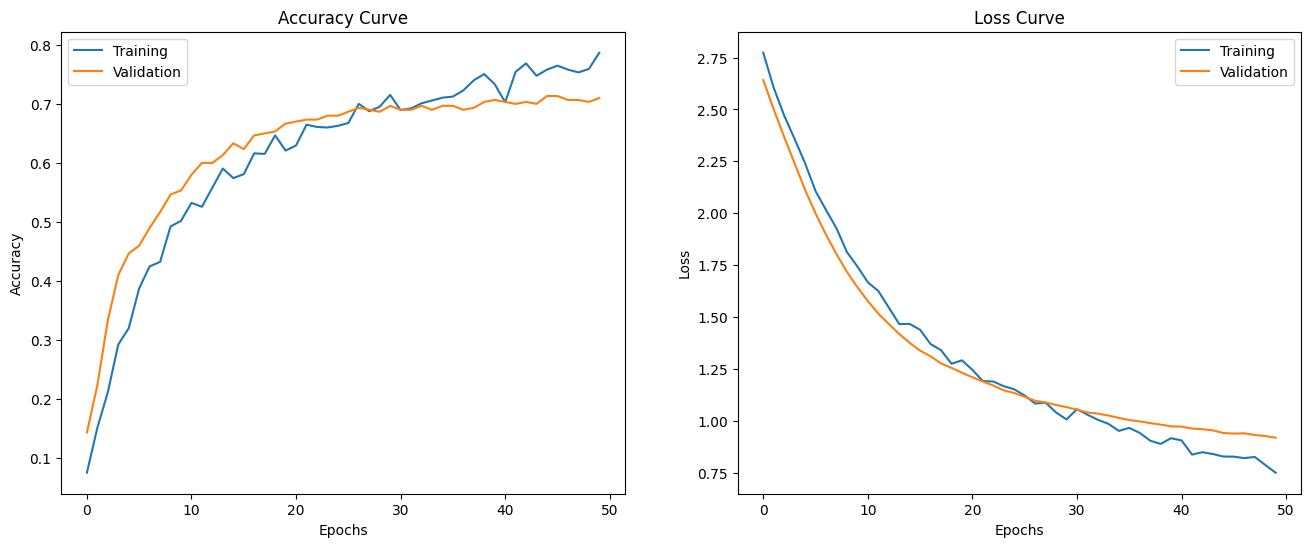

In [ ]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
plt.title('Accuracy Curve')
plt.plot(train_acc, label='Training')
plt.plot(val_acc, label='Validation')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.title('Loss Curve')
plt.plot(train_loss, label='Training')
plt.plot(val_loss, label='Validation')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

In [ ]:
test_dir = '/content/indonesian-batik-motifs-corak-app/DATASET/DATASET/TEST'

for motive in motives_dict.keys():
    images_list = os.listdir(os.path.join(test_dir, motive))
#     plt.figure(figsize=(16, 20))

    correct_count = 0

    for idx, image in enumerate(images_list):
        img_path = f'/content/indonesian-batik-motifs-corak-app/DATASET/DATASET/TEST/{motive}/{image}'
        img = load_img(img_path, target_size=(224, 224))

        img_array = img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)

        motives_list = list(motives_dict.keys())
        prediction = model(img_array)
        pred_idx = np.argmax(prediction)
        pred_motive = motives_list[pred_idx]
        pred_confidence = prediction[0][pred_idx] * 100

        if pred_motive == motive:
            correct_count += 1

#         plt.subplot(5, 4, idx+1)
#         plt.title(f'Actual: {motive}\nPrediction: {pred_motive} {pred_confidence:.2f}%')
#         plt.imshow(img)
#         plt.axis('off')

    print(f'{motive} Predictions --> {correct_count}/20 correct')
# plt.show()

Batik Bali Predictions --> 10/20 correct
Batik Betawi Predictions --> 11/20 correct
Batik Cendrawasih Predictions --> 13/20 correct
Batik Dayak Predictions --> 14/20 correct
Batik Geblek Renteng Predictions --> 12/20 correct
Batik Ikat Celup Predictions --> 14/20 correct
Batik Insang Predictions --> 19/20 correct
Batik Kawung Predictions --> 16/20 correct
Batik Lasem Predictions --> 12/20 correct
Batik Megamendung Predictions --> 19/20 correct
Batik Pala Predictions --> 11/20 correct
Batik Parang Predictions --> 16/20 correct
Batik Poleng Predictions --> 19/20 correct
Batik Sekar Jagad Predictions --> 11/20 correct
Batik Tambal Predictions --> 16/20 correct
